In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
import plotly.express as px
import plotly.graph_objects as go

In [4]:
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

%matplotlib inline

In [5]:
fund_master = pd.read_csv(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\data\01_fund_master.csv")

nav_history = pd.read_csv(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\data\02_nav_history.csv")

aum = pd.read_csv(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\data\03_aum_by_fund_house.csv")

sip = pd.read_csv(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\data\04_monthly_sip_inflows.csv")

category = pd.read_csv(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\data\05_category_inflows.csv")

folio = pd.read_csv(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\data\06_industry_folio_count.csv")

performance = pd.read_csv(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\data\07_scheme_performance.csv")

investor = pd.read_csv(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\data\08_investor_transactions.csv")

portfolio = pd.read_csv(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\data\09_portfolio_holdings.csv")

benchmark = pd.read_csv(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\data\10_benchmark_indices.csv")

In [6]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Investor": investor,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.shape)

Fund Master
(40, 15)
NAV History
(46000, 3)
AUM
(90, 5)
SIP
(48, 6)
Category
(144, 3)
Folio
(21, 6)
Performance
(40, 19)
Investor
(32778, 13)
Portfolio
(322, 8)
Benchmark
(8050, 3)


In [7]:
for name, df in datasets.items():

    print()

    print(name)

    print(df.isnull().sum())


Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

NAV History
amfi_code    0
date         0
nav          0
dtype: int64

AUM
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

SIP
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

Category
month               0
category            0
net_inflow_crore    0
dtype: int64

Folio
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore

In [8]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

category["month"] = pd.to_datetime(category["month"])

folio["month"] = pd.to_datetime(folio["month"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [11]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


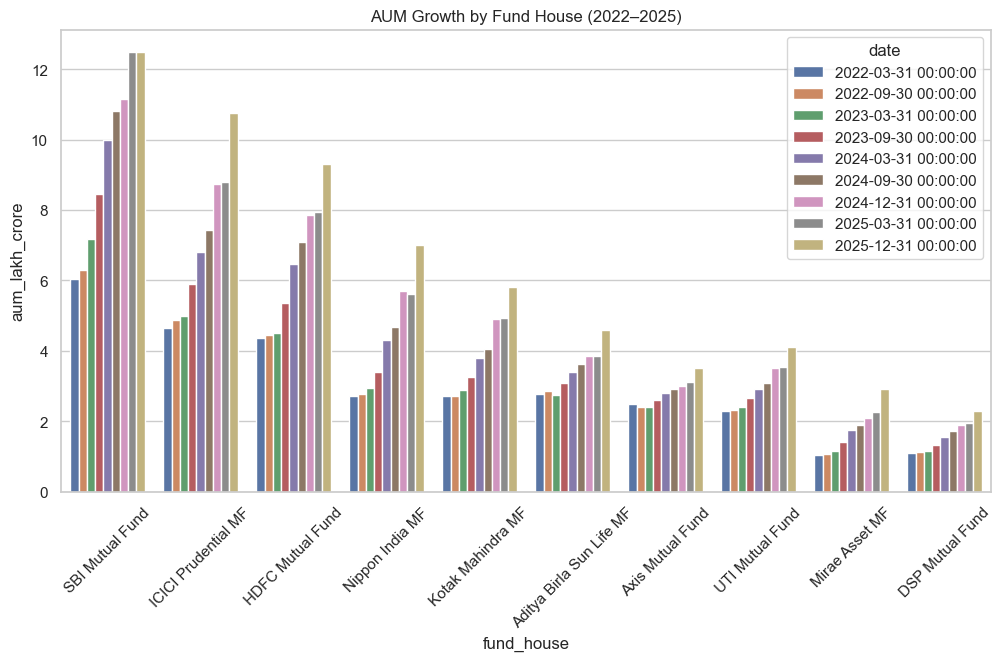

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="date"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xticks(rotation=45)

plt.show()

In [21]:
plt.savefig(
    r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [20]:
import os

os.path.exists(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts")

True

In [23]:
print(nav_history.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [24]:
import plotly.express as px

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

In [25]:
fig.show()

In [26]:
plt.savefig(
    r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

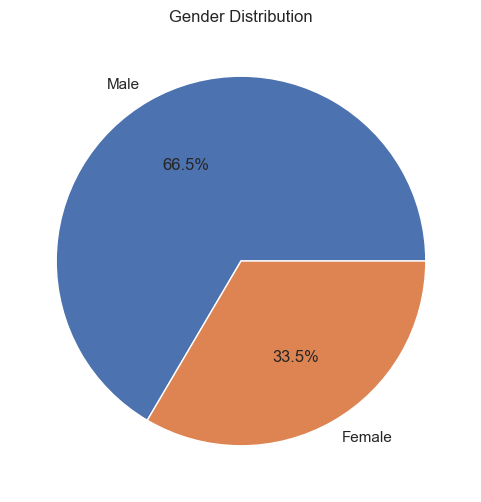

In [28]:
gender = investor["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\gender_pie.png")

plt.show()

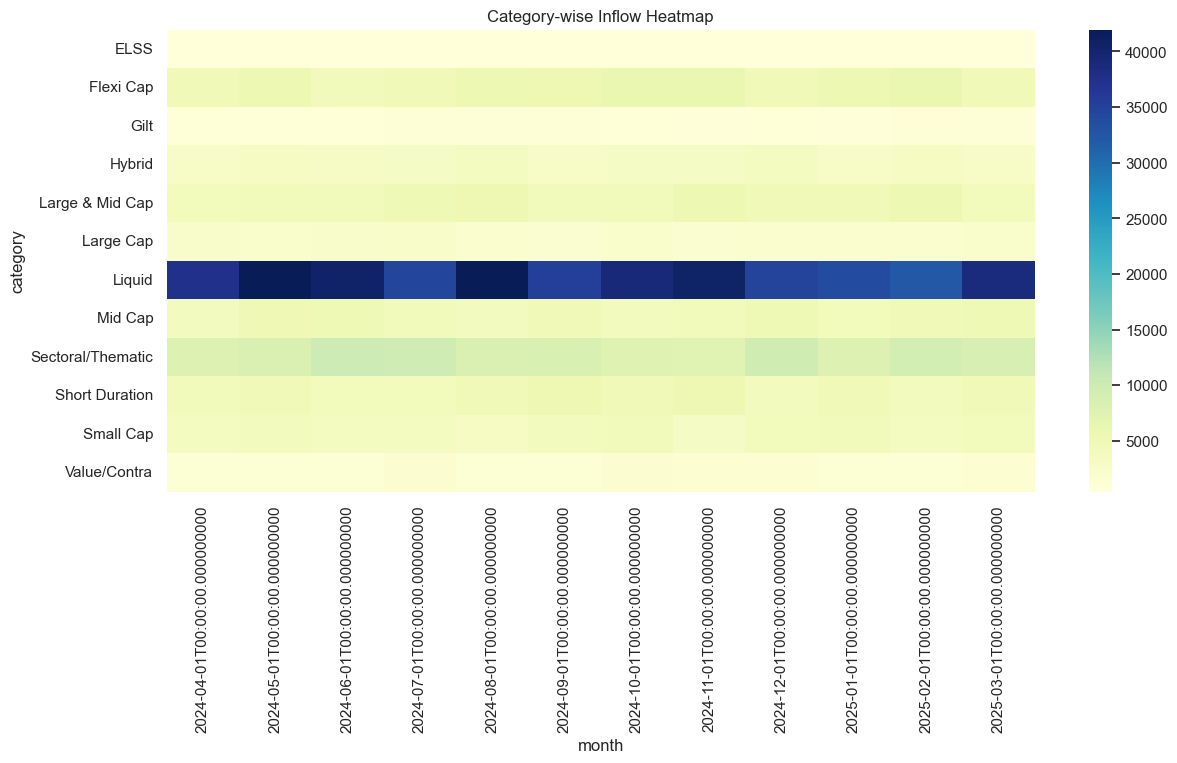

In [30]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category-wise Inflow Heatmap")

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\heatmap.png")

plt.show()

 nav_trend.png
│   ├── aum_growth.png
│   ├── sip_trend.png
│   ├── heatmap.png
│   ├── age_pie.png
│   ├── gender_pie.png
│   ├── state_bar.png
│   ├── folio_growth.png
│   ├── correlation.png
│   └── sector_donut.png
│

In [35]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

In [36]:
nav_history = nav_history.sort_values(["amfi_code", "date"])

In [37]:
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [38]:
selected_codes = nav_history["amfi_code"].unique()[:10]

selected = nav_history[
    nav_history["amfi_code"].isin(selected_codes)
]

In [39]:
selected_funds = selected.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

In [40]:
corr = selected_funds.corr()

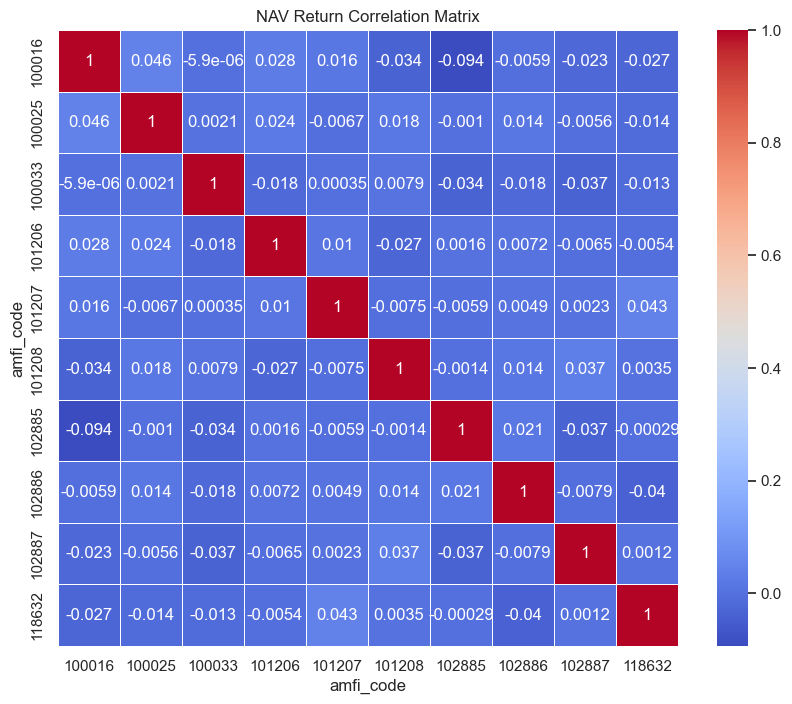

In [42]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    linewidths=0.5
)

plt.title("NAV Return Correlation Matrix")

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\correlation.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [45]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Peak: ₹{max_row['sip_inflow_crore']:.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\sip_trend.png")

<Figure size 640x480 with 0 Axes>

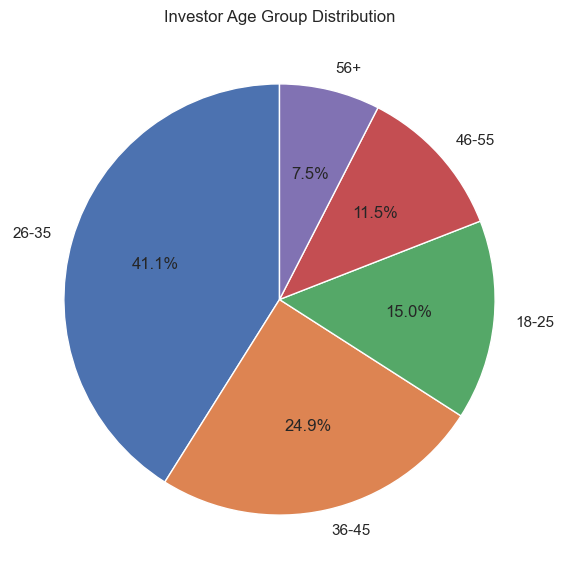

In [46]:
age = investor["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age,
    labels=age.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\age_pie.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

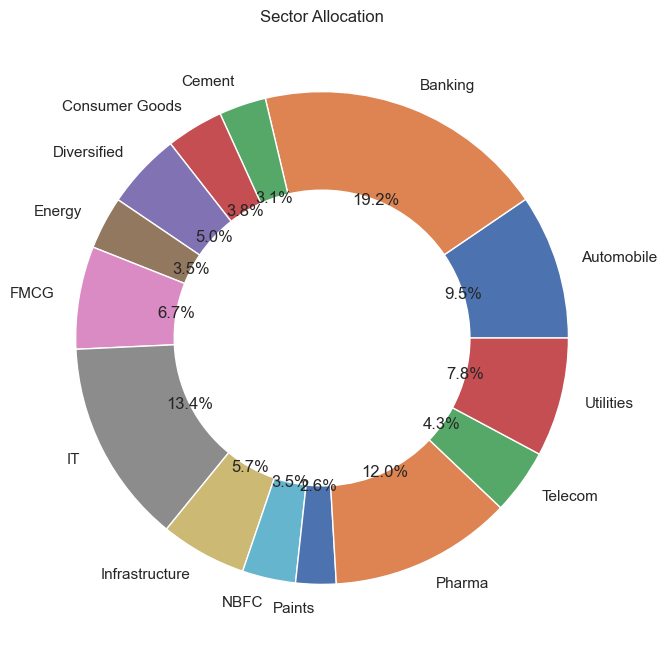

In [47]:
sector = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation")

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\sector_donut.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

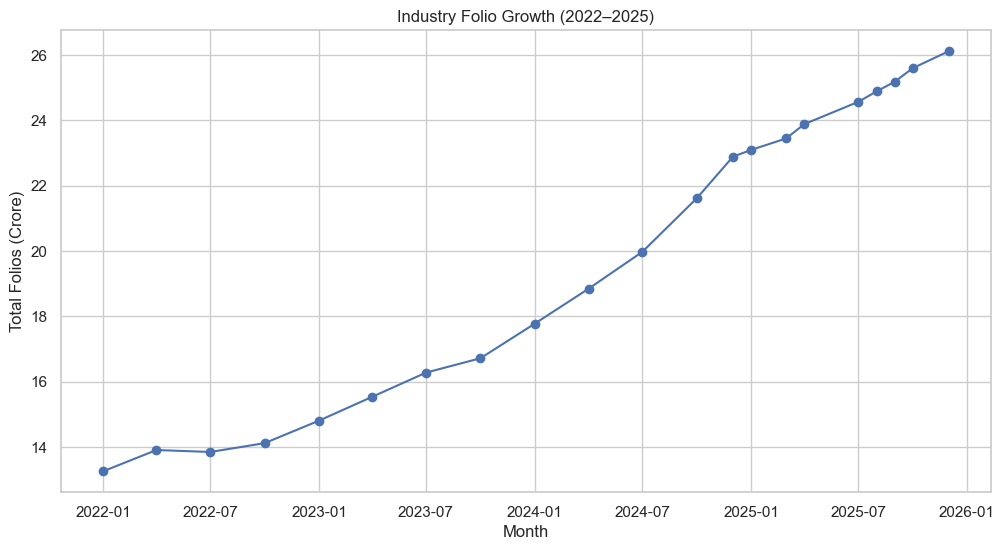

In [48]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth (2022–2025)")

plt.xlabel("Month")

plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\folio_growth.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

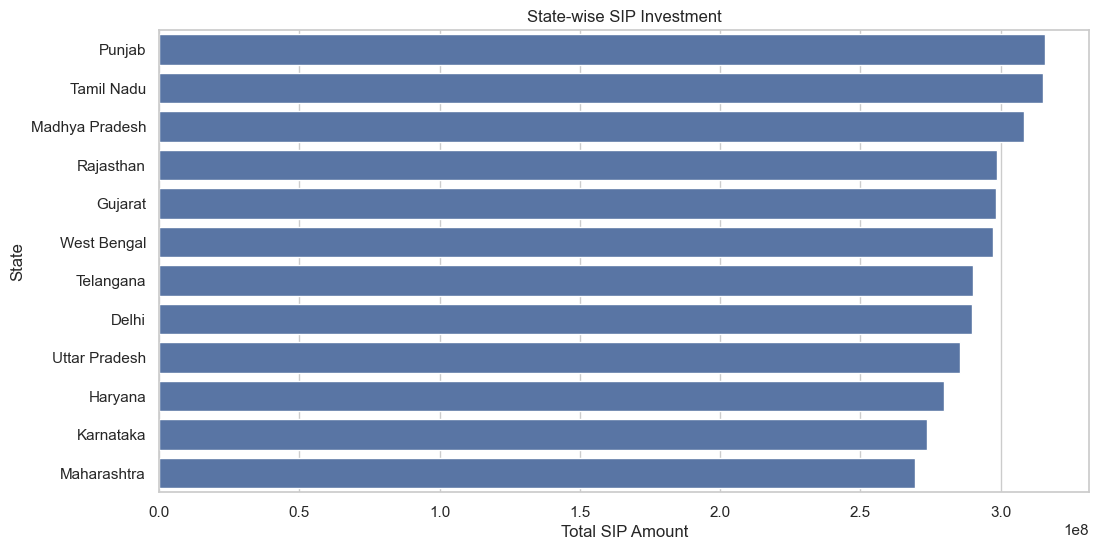

In [49]:
state = (
    investor
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state.values,
    y=state.index
)

plt.title("State-wise SIP Investment")

plt.xlabel("Total SIP Amount")

plt.ylabel("State")

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\state_bar.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

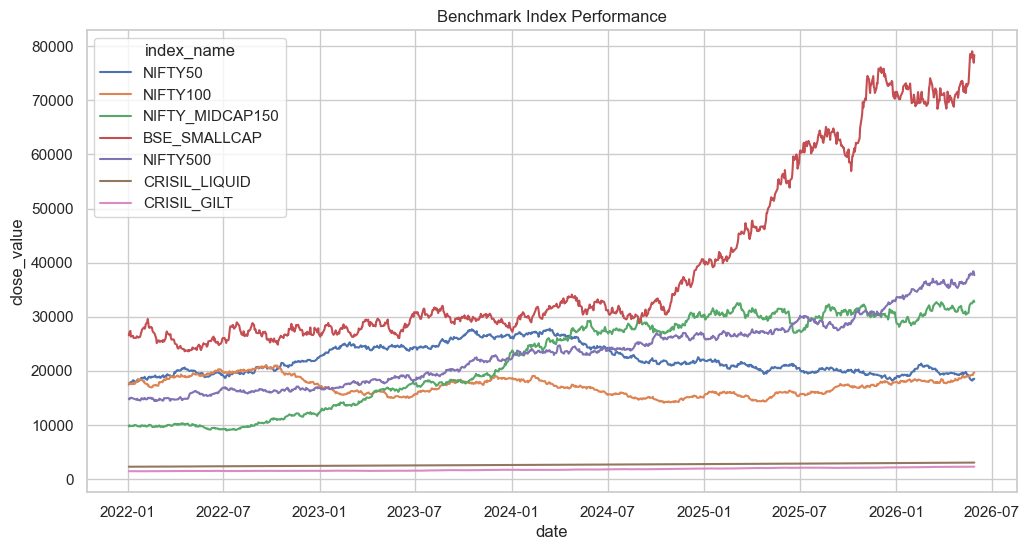

In [50]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=benchmark,
    x="date",
    y="close_value",
    hue="index_name"
)

plt.title("Benchmark Index Performance")

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\benchmark_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

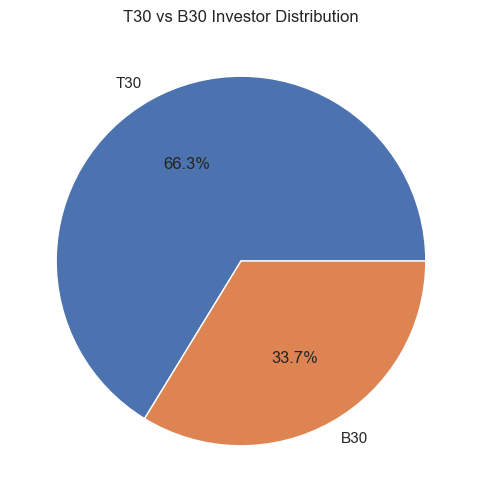

In [51]:
tier = investor["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\city_tier.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

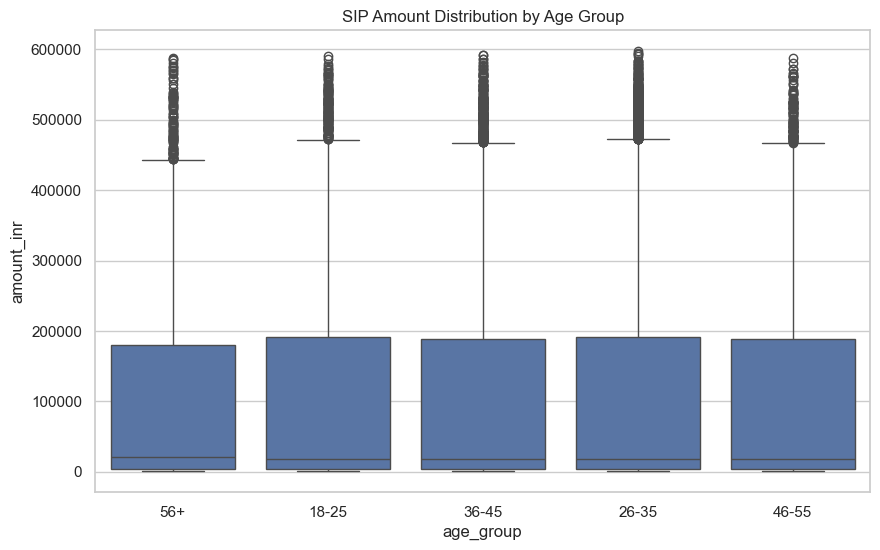

In [52]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\age_boxplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

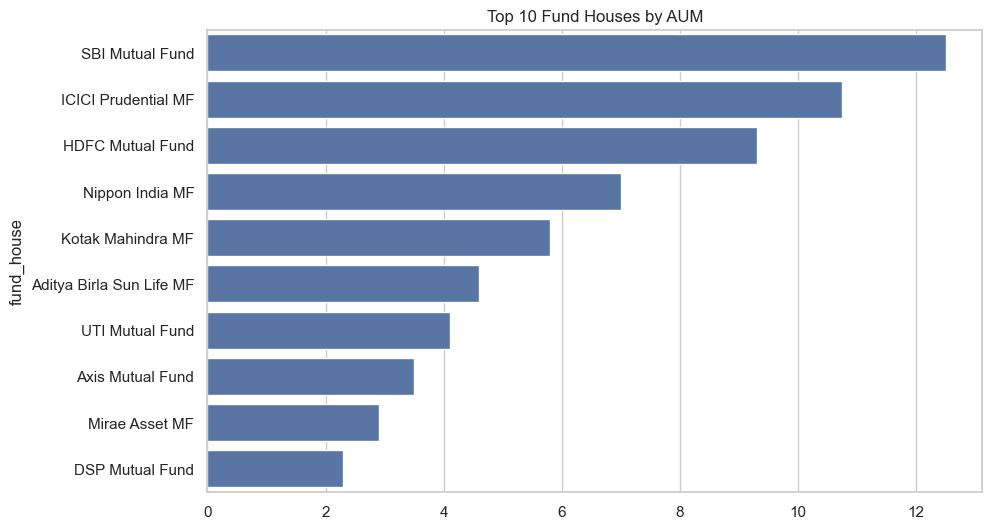

In [53]:
top = (
    aum
    .groupby("fund_house")["aum_lakh_crore"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top.values,
    y=top.index
)

plt.title("Top 10 Fund Houses by AUM")

plt.savefig(r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Exploratory Data Analysis (EDA)\charts\top_fundhouses.png",
            dpi=300,
            bbox_inches="tight")

plt.show()